# Formal Statistical Tests for Homoscedasticity
## Applied Econometrics 
**Dataset:** `wage1` (Wooldridge, 2015) — Current Population Survey (CPS) cross-section  
**Dependent Variable:** $\ln(\text{wage})$  
**Regressors:** Education, Experience, Experience$^2$, Female dummy  

---

### References
- Breusch, T.S. & Pagan, A.R. (1979). *Econometrica*, 47(5), 1287–1294.
- Koenker, R. (1981). *Journal of Econometrics*, 17(1), 107–112.
- White, H. (1980). *Econometrica*, 48(4), 817–838.
- Goldfeld, S.M. & Quandt, R.E. (1965). *JASA*, 60(310), 539–547.
- Park, R.E. (1966). *Econometrica*, 34(4), 888.
- Greene, W.H. (2018). *Econometric Analysis* (8th ed.). Pearson.
- Wooldridge, J.M. (2015). *Introductory Econometrics* (6th ed.). Cengage.

---

## 0. Environment Setup

In [1]:
# ── Environment Setup ────────────────────────────────────────────────────────
import subprocess, sys

REQUIRED = ['wooldridge', 'statsmodels', 'matplotlib', 'seaborn', 'numpy', 'pandas', 'scipy']
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

# ── Global Plot Style ────────────────────────────────────────────────────────
DEEP_BLUE  = '#1a3a5c'
TEAL       = '#2a7f7f'
AMBER      = '#d4860a'
STEEL      = '#4a6fa5'
LIGHT_GREY = '#f5f6fa'

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : LIGHT_GREY,
    'axes.edgecolor'    : DEEP_BLUE,
    'axes.linewidth'    : 1.2,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : DEEP_BLUE,
    'axes.labelcolor'   : DEEP_BLUE,
    'axes.labelsize'    : 10,
    'xtick.color'       : DEEP_BLUE,
    'ytick.color'       : DEEP_BLUE,
    'font.family'       : 'serif',
    'grid.color'        : 'white',
    'grid.linewidth'    : 0.8,
    'legend.framealpha' : 0.9,
    'legend.fontsize'   : 9,
})

print('All packages loaded successfully.')
print(f'  NumPy      : {np.__version__}')
print(f'  pandas     : {pd.__version__}')
print(f'  statsmodels: {sm.__version__}')

Installing wooldridge...



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


All packages loaded successfully.
  NumPy      : 2.3.5
  pandas     : 2.3.3
  statsmodels: 0.14.6


## 1. Data Loading and Preparation

We use the `wage1` dataset from Wooldridge (2015), which is a cross-section of 526 workers drawn from the 1976 Current Population Survey. The variables of interest are:

| Variable  | Description                                              |
|-----------|----------------------------------------------------------|
| `wage`    | Hourly earnings in USD                                   |
| `lwage`   | Natural log of hourly wage (pre-computed in dataset)     |
| `educ`    | Years of schooling                                       |
| `exper`   | Years of potential experience                            |
| `expersq` | Experience squared (pre-computed in dataset)             |
| `female`  | Binary indicator: 1 = female, 0 = male                  |

**Model specification:**
$$\ln(\text{wage}_i) = \beta_0 + \beta_1\,\text{educ}_i + \beta_2\,\text{exper}_i + \beta_3\,\text{exper}_i^2 + \beta_4\,\text{female}_i + \varepsilon_i$$

This is the standard Mincer earnings equation. Under OLS, we require $\mathrm{Var}(\varepsilon_i\mid \mathbf{x}_i) = \sigma^2$ for valid inference.

In [2]:
# ── Data Loading ─────────────────────────────────────────────────────────────
try:
    import wooldridge as woo
    df = woo.dataWoo('wage1')
    print('Dataset loaded via wooldridge package.')
except Exception as e:
    # Fallback: load from Wooldridge's public GitHub repository
    print(f'wooldridge package failed ({e}). Attempting URL fallback...')
    url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/wage1.csv'
    df = pd.read_csv(url)
    print('Dataset loaded via URL fallback.')

# ── Variable Selection and Integrity Checks ───────────────────────────────────
COLS = ['wage', 'educ', 'exper', 'expersq', 'female']
df = df[COLS].copy()

# Defensive: compute expersq if missing
if 'expersq' not in df.columns:
    df['expersq'] = df['exper'] ** 2

# Defensive: compute log wage
assert (df['wage'] > 0).all(), 'Non-positive wages detected — cannot take log.'
df['lwage'] = np.log(df['wage'])

# Missing data report
missing = df.isnull().sum()
if missing.any():
    print(f'Missing values detected:\n{missing[missing > 0]}')
    df = df.dropna()
    print(f'After dropping: {len(df)} observations remain.')
else:
    print(f'No missing values. Sample size: n = {len(df)}')

print('\nDescriptive Statistics:')
display(df.describe().round(4))

Dataset loaded via wooldridge package.
No missing values. Sample size: n = 526

Descriptive Statistics:


,wage,educ,exper,expersq,female,lwage
count,526.0000,526.0000,526.0000,526.0000,526.0000,526.0000
mean,5.8961,12.5627,17.0171,473.4354,0.4791,1.6233
std,3.6931,2.7690,13.5722,616.0448,0.5000,0.5315
min,0.5300,0.0000,1.0000,1.0000,0.0000,-0.6349
25%,3.3300,12.0000,5.0000,25.0000,0.0000,1.2030
50%,4.6500,12.0000,13.5000,182.5000,0.0000,1.5369
75%,6.8800,14.0000,26.0000,676.0000,1.0000,1.9286
max,24.9800,18.0000,51.0000,2601.0000,1.0000,3.2181


## 2. OLS Estimation

We estimate the Mincer log-wage equation via OLS. Under homoscedasticity, the
Gauss–Markov theorem guarantees that OLS is BLUE and that the reported standard
errors are consistent (Greene, 2018, §9.2). The regression summary below uses
conventional (non-robust) standard errors; we assess their validity in subsequent
sections.

In [ ]:
# ── OLS Estimation ────────────────────────────────────────────────────────────
# Design matrix: constant + regressors
X = sm.add_constant(df[['educ', 'exper', 'expersq', 'female']])
y = df['lwage']

model  = sm.OLS(y, X)
result = model.fit()

print(result.summary(
    title='OLS Regression: Log Wage (Mincer Equation)',
    xname=['Intercept', 'Education (yrs)', 'Experience (yrs)',
           'Experience²', 'Female']
))

# ── Extract diagnostic quantities ─────────────────────────────────────────────
resid       = result.resid                          # OLS residuals ε̂_i
fitted      = result.fittedvalues                   # ŷ_i
resid_sq    = resid ** 2                            # ε̂_i²
sigma_hat   = np.sqrt(result.mse_resid)             # σ̂ = √(RSS / (n−k))
std_resid   = resid / sigma_hat                     # Standardised residuals
sqrt_abs_sr = np.sqrt(np.abs(std_resid))            # Scale-location ordinate
n, k        = result.nobs, result.df_model + 1      # n observations, k params

print(f'\nModel diagnostics:')
print(f'  n = {int(n)},  k = {int(k)},  df_residual = {int(result.df_resid)}')
print(f'  R²   = {result.rsquared:.4f}')
print(f'  AIC  = {result.aic:.2f},  BIC = {result.bic:.2f}')
print(f'  σ̂   = {sigma_hat:.4f}')

                  OLS Regression: Log Wage (Mincer Equation)                  
Dep. Variable:                  lwage   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     86.69
Date:                Sat, 02 May 2026   Prob (F-statistic):           2.03e-56
Time:                        13:15:50   Log-Likelihood:                -279.27
No. Observations:                 526   AIC:                             568.5
Df Residuals:                     521   BIC:                             589.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3905      0.102  

### Coefficient Interpretation

Since the dependent variable is $\ln(\text{wage})$, estimated coefficients are interpreted
as approximate semi-elasticities:

- **Education:** Each additional year of schooling is associated with an approximately
  $100\hat{\beta}_1\%$ increase in the hourly wage, *ceteris paribus*.
- **Experience:** The effect of experience is non-linear (inverted-U) due to the
  quadratic term; the return diminishes after the peak experience level
  $\hat{\text{exper}}^* = -\hat{\beta}_2 / (2\hat{\beta}_3)$.
- **Female:** The coefficient on the binary gender dummy captures the conditional
  log-wage differential attributed to gender, holding human capital constant.

---

## 3. Graphical Diagnostics

Before applying formal tests, visual inspection of the residuals is an indispensable
preliminary step. Graphs reveal patterns — fan shapes, curvature, outlier clustering —
that summary statistics and $p$-values cannot convey (Fox, 2016; Tukey, 1977).

We generate four diagnostic plots:
1. **Residuals vs. Fitted** — detects global heteroscedasticity and functional-form misspecification.
2. **Residuals vs. Education** — assesses variance dependence on years of schooling.
3. **Residuals vs. Experience** — assesses variance dependence on years of experience.
4. **Scale–Location** — stabilises the scale of residuals for cleaner visual assessment of spread.

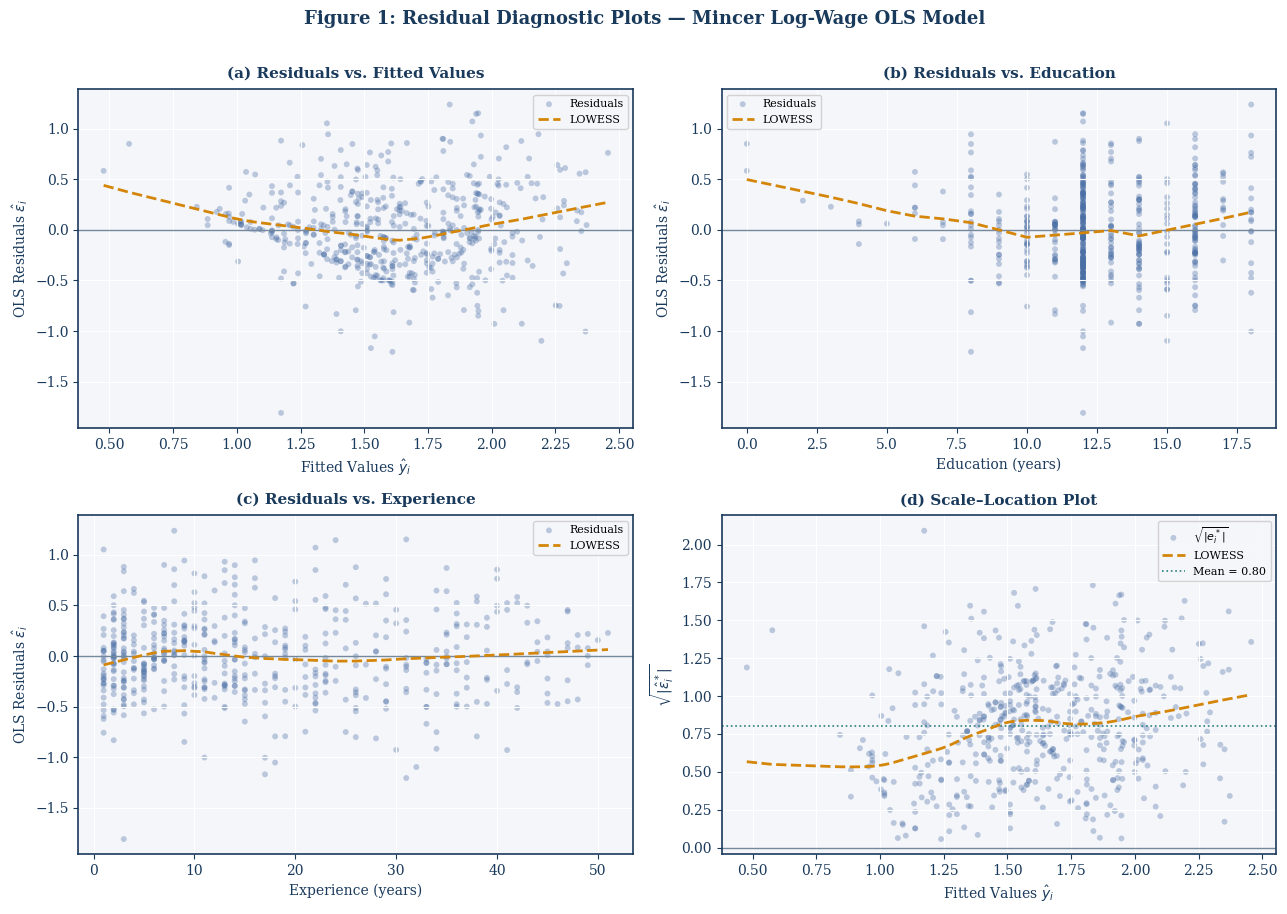

In [4]:
# ── Helper: add LOWESS smoother to an axis ────────────────────────────────────
def add_lowess(ax, x, y, frac=0.5, color=AMBER, lw=2.0, label='LOWESS'):
    """Overlay a locally-weighted scatterplot smoother on axis `ax`."""
    order = np.argsort(x)
    xs, ys = np.asarray(x)[order], np.asarray(y)[order]
    smooth = lowess(ys, xs, frac=frac, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1],
            color=color, lw=lw, linestyle='--', label=label, zorder=4)


# ── Helper: style an axis consistently ────────────────────────────────────────
def style_ax(ax, xlabel, ylabel, title):
    ax.axhline(0, color=DEEP_BLUE, linewidth=1.0, linestyle='-', alpha=0.6)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color=DEEP_BLUE, pad=8)
    ax.legend(framealpha=0.85, fontsize=8)
    ax.grid(True, which='major', color='white', linewidth=0.8)


# ── Figure 1: Four Diagnostic Plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Figure 1: Residual Diagnostic Plots — Mincer Log-Wage OLS Model',
    fontsize=13, fontweight='bold', color=DEEP_BLUE, y=1.01
)
scatter_kw = dict(alpha=0.35, s=18, color=STEEL, edgecolors='none')

# ── Panel (a): Residuals vs Fitted ────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(fitted, resid, **scatter_kw, label='Residuals')
add_lowess(ax, fitted, resid)
style_ax(ax,
    xlabel='Fitted Values $\\hat{y}_i$',
    ylabel='OLS Residuals $\\hat{\\varepsilon}_i$',
    title='(a) Residuals vs. Fitted Values'
)

# ── Panel (b): Residuals vs Education ────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(df['educ'], resid, **scatter_kw, label='Residuals')
add_lowess(ax, df['educ'], resid)
style_ax(ax,
    xlabel='Education (years)',
    ylabel='OLS Residuals $\\hat{\\varepsilon}_i$',
    title='(b) Residuals vs. Education'
)

# ── Panel (c): Residuals vs Experience ───────────────────────────────────────
ax = axes[1, 0]
ax.scatter(df['exper'], resid, **scatter_kw, label='Residuals')
add_lowess(ax, df['exper'], resid)
style_ax(ax,
    xlabel='Experience (years)',
    ylabel='OLS Residuals $\\hat{\\varepsilon}_i$',
    title='(c) Residuals vs. Experience'
)

# ── Panel (d): Scale–Location ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.scatter(fitted, sqrt_abs_sr, **scatter_kw, label='$\\sqrt{|e_i^*|}$')
add_lowess(ax, fitted, sqrt_abs_sr, frac=0.5)
ax.axhline(np.mean(sqrt_abs_sr), color=TEAL, lw=1.2,
           linestyle=':', label=f'Mean = {np.mean(sqrt_abs_sr):.2f}')
style_ax(ax,
    xlabel='Fitted Values $\\hat{y}_i$',
    ylabel='$\\sqrt{|\\hat{\\varepsilon}_i^*|}$',
    title='(d) Scale–Location Plot'
)

plt.tight_layout()
plt.savefig('fig1_diagnostic_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of Graphical Diagnostics

**Panel (a) — Residuals vs. Fitted Values:**  
The residuals should be symmetrically scattered around the horizontal zero line with
roughly constant spread. A funnel or fan shape — where the vertical dispersion of
residuals increases (or decreases) with $\hat{y}_i$ — is direct visual evidence of
heteroscedasticity. Any systematic non-linear pattern (e.g., U-shape or arc) would
additionally suggest functional-form misspecification. The LOWESS smoother highlights
any systematic trend in the mean of residuals.

**Panel (b) — Residuals vs. Education:**  
Increasing spread of residuals at higher education levels would imply that wage
dispersion grows with schooling — a pattern documented in the returns-to-education
literature (Card, 1999). Sparse data at low education values (0–8 years) can also create
apparent asymmetry without structural heteroscedasticity.

**Panel (c) — Residuals vs. Experience:**  
Experience is the primary ordering variable for the Goldfeld–Quandt test in Section 4.3.
If residual spread is notably higher at low experience levels (young workers have more
heterogeneous wage outcomes), the variance is monotonically decreasing — a common
finding in cross-sectional earnings regressions.

**Panel (d) — Scale–Location:**  
This plot uses $\sqrt{|\hat{\varepsilon}_i^*|}$ (square root of absolute standardised
residuals) rather than raw residuals. The square root transformation compresses the
scale and makes trends in the second moment easier to detect visually. A positive
slope in the LOWESS smoother indicates that variance grows with the fitted value;
a flat smoother is consistent with homoscedasticity.

---

## 4. Formal Heteroscedasticity Tests

### 4.1 Breusch–Pagan / Koenker Test

**Theoretical Background.**  
Breusch & Pagan (1979) proposed a Lagrange Multiplier (LM) test for the null hypothesis
$H_0: \mathrm{Var}(\varepsilon_i \mid \mathbf{x}_i) = \sigma^2$ (constant). The procedure
regresses squared OLS residuals on a set of auxiliary variables $\mathbf{z}_i$ and tests
whether $\mathbf{z}_i$ has joint explanatory power. The original statistic requires
normality; Koenker (1981) proposed a studentized variant that is valid under only
finite fourth moments.

**Auxiliary regression:**
$$\hat{\varepsilon}_i^2 = \delta_0 + \mathbf{z}_i'\boldsymbol{\gamma} + \eta_i$$

**Test statistic:**
$$\mathrm{LM} = n \cdot R^2_{\mathrm{aux}} \xrightarrow{d} \chi^2_p \quad \text{under } H_0$$

where $p$ = number of slope coefficients in $\mathbf{z}_i$.

In [5]:
# ── 4.1 Breusch–Pagan / Koenker Test ─────────────────────────────────────────
print('=' * 65)
print('TEST 1: Breusch–Pagan / Koenker (BP/K) Test')
print('=' * 65)
print('H₀: Var(ε_i | x_i) = σ²  (homoscedasticity)')
print('H₁: Var(ε_i | x_i) = σ²_i  (heteroscedasticity)\n')

# Auxiliary regressors: the original regressors (excluding the constant)
# z_i = (educ_i, exper_i, expersq_i, female_i)
Z = X  # same as design matrix (includes constant)

# ── statsmodels implementation ────────────────────────────────────────────────
# het_breuschpagan returns: (LM, LM_pval, F, F_pval)
# The 'robust' (Koenker) version is computed internally when the statistic
# is the nR² form under studentization.
lm_bp, pval_bp, f_bp, pval_f_bp = het_breuschpagan(resid, Z)

print(f'  [statsmodels] BP LM statistic : {lm_bp:.4f}')
print(f'  [statsmodels] BP p-value      : {pval_bp:.4f}')
print(f'  [statsmodels] BP F-statistic  : {f_bp:.4f}')
print(f'  [statsmodels] BP F p-value    : {pval_f_bp:.4f}\n')

# ── Manual implementation (Koenker robust version) ────────────────────────────
print('  --- Manual Implementation (Koenker Studentized Version) ---')

# Step 1: centered squared residuals
# u_i = ε̂_i² − σ̂²  (centered)
u_i = resid_sq - np.mean(resid_sq)

# Step 2: auxiliary regression of u_i on z_i
Z_aux = Z.copy()  # includes constant + 4 regressors
aux_model  = sm.OLS(u_i, Z_aux)
aux_result = aux_model.fit()

R2_aux = aux_result.rsquared
p      = aux_result.df_model       # number of slope coefficients

# Koenker statistic: n·R²_aux (robust to non-normality)
LM_koenker = int(n) * R2_aux
pval_koenker = 1 - stats.chi2.cdf(LM_koenker, df=p)

print(f'  Auxiliary R²_aux              : {R2_aux:.6f}')
print(f'  Degrees of freedom p          : {int(p)}')
print(f'  Koenker LM = n·R²_aux         : {LM_koenker:.4f}')
print(f'  χ²({int(p)}) critical (α=0.05) : {stats.chi2.ppf(0.95, df=p):.4f}')
print(f'  Koenker p-value               : {pval_koenker:.4f}\n')

alpha = 0.05
conclusion_bp = 'REJECT H₀' if pval_koenker < alpha else 'FAIL TO REJECT H₀'
print(f'  Conclusion (α = {alpha}): {conclusion_bp}')
if pval_koenker < alpha:
    print('  → Evidence of heteroscedasticity. OLS standard errors are unreliable.')
else:
    print('  → Insufficient evidence against homoscedasticity at this level.')

TEST 1: Breusch–Pagan / Koenker (BP/K) Test
H₀: Var(ε_i | x_i) = σ²  (homoscedasticity)
H₁: Var(ε_i | x_i) = σ²_i  (heteroscedasticity)

  [statsmodels] BP LM statistic : 9.9839
  [statsmodels] BP p-value      : 0.0407
  [statsmodels] BP F-statistic  : 2.5201
  [statsmodels] BP F p-value    : 0.0404

  --- Manual Implementation (Koenker Studentized Version) ---
  Auxiliary R²_aux              : 0.018981
  Degrees of freedom p          : 4
  Koenker LM = n·R²_aux         : 9.9839
  χ²(4) critical (α=0.05) : 9.4877
  Koenker p-value               : 0.0407

  Conclusion (α = 0.05): REJECT H₀
  → Evidence of heteroscedasticity. OLS standard errors are unreliable.


### 4.2 White's General Test

**Theoretical Background.**  
White (1980) proposed an omnibus test that does not require pre-specifying the functional
form of heteroscedasticity. The auxiliary regression includes all regressors $\mathbf{x}_i$,
their element-wise squares $x_{ij}^2$, and all pairwise cross-products $x_{ij} x_{il}$,
$j < l$. This constitutes a second-order polynomial approximation to the unknown
variance function:

$$\hat{\varepsilon}_i^2 = \alpha + \mathbf{x}_i'\boldsymbol{\gamma}_1 + (\mathbf{x}_i \otimes \mathbf{x}_i)'\boldsymbol{\gamma}_2 + u_i$$

With $k$ regressors (excluding the constant), the auxiliary regression has
$q = k + k(k+1)/2$ slope coefficients and $k(k+1)/2$ additional degrees of freedom
relative to the BP test. This flexibility comes at a power cost in moderate samples.

**Test statistic:** $W = n \cdot R^2_{\mathrm{aux}} \xrightarrow{d} \chi^2_q$ under $H_0$.

In [6]:
# ── 4.2 White's General Test ──────────────────────────────────────────────────
print('=' * 65)
print('TEST 2: White\'s General Test (1980)')
print('=' * 65)
print('H₀: Var(ε_i | x_i) = σ²  (homoscedasticity)')
print('H₁: Var(ε_i | x_i) depends on regressors or their squares/products\n')

# ── statsmodels implementation ────────────────────────────────────────────────
# het_white returns: (LM, LM_pval, F, F_pval)
lm_white, pval_white, f_white, pval_f_white = het_white(resid, X)

print(f'  [statsmodels] White LM statistic : {lm_white:.4f}')
print(f'  [statsmodels] White p-value      : {pval_white:.4f}')
print(f'  [statsmodels] White F-statistic  : {f_white:.4f}')
print(f'  [statsmodels] White F p-value    : {pval_f_white:.4f}\n')

# ── Manual construction of the White auxiliary regression ────────────────────
print('  --- Manual Implementation ---')
regressors_raw = ['educ', 'exper', 'expersq', 'female']
white_aux = sm.add_constant(df[regressors_raw].copy())

# Add squared terms
for col in regressors_raw:
    white_aux[f'{col}_sq'] = df[col] ** 2

# Add cross-products (upper triangle only to avoid duplication)
for i, ci in enumerate(regressors_raw):
    for j, cj in enumerate(regressors_raw):
        if j > i:
            white_aux[f'{ci}_x_{cj}'] = df[ci] * df[cj]

q = white_aux.shape[1] - 1   # number of slope coefficients
print(f'  Auxiliary regressors (excl. constant): q = {q}')
print(f'  → Original regressors: {len(regressors_raw)}')
print(f'  → Squared terms      : {len(regressors_raw)}')
print(f'  → Cross-products     : {len(regressors_raw)*(len(regressors_raw)-1)//2}\n')

white_model  = sm.OLS(resid_sq, white_aux)
white_result = white_model.fit()
R2_white     = white_result.rsquared
LM_white_man = int(n) * R2_white
pval_white_man = 1 - stats.chi2.cdf(LM_white_man, df=q)

print(f'  Manual White LM = n·R²_aux : {LM_white_man:.4f}')
print(f'  χ²({q}) critical (α=0.05)  : {stats.chi2.ppf(0.95, df=q):.4f}')
print(f'  Manual White p-value       : {pval_white_man:.4f}\n')

conclusion_white = 'REJECT H₀' if pval_white < alpha else 'FAIL TO REJECT H₀'
print(f'  Conclusion (α = {alpha}): {conclusion_white}')
if pval_white < alpha:
    print('  → Evidence of heteroscedasticity of unspecified functional form.')
print()
print('  Comparison with BP/Koenker:')
print(f'    BP/Koenker LM = {LM_koenker:.4f}  (df = {int(p)},  p = {pval_koenker:.4f})')
print(f'    White      LM = {lm_white:.4f}  (df = {int(q)},  p = {pval_white:.4f})')

TEST 2: White's General Test (1980)
H₀: Var(ε_i | x_i) = σ²  (homoscedasticity)
H₁: Var(ε_i | x_i) depends on regressors or their squares/products

  [statsmodels] White LM statistic : 19.9303
  [statsmodels] White p-value      : 0.0684
  [statsmodels] White F-statistic  : 1.6836
  [statsmodels] White F p-value    : 0.0669

  --- Manual Implementation ---
  Auxiliary regressors (excl. constant): q = 14
  → Original regressors: 4
  → Squared terms      : 4
  → Cross-products     : 6

  Manual White LM = n·R²_aux : 19.9303
  χ²(14) critical (α=0.05)  : 23.6848
  Manual White p-value       : 0.1324

  Conclusion (α = 0.05): FAIL TO REJECT H₀

  Comparison with BP/Koenker:
    BP/Koenker LM = 9.9839  (df = 4,  p = 0.0407)
    White      LM = 19.9303  (df = 14,  p = 0.0684)


### 4.3 Goldfeld–Quandt Test

**Theoretical Background.**  
Goldfeld & Quandt (1965) proposed a direct variance-comparison test that is particularly
effective when heteroscedasticity is monotonic in a known ordering variable. The procedure
partitions the ordered sample into two groups, estimates the OLS model separately on
each, and computes the ratio of residual sum-of-squares estimates:

$$F_{\mathrm{GQ}} = \frac{\hat{\sigma}^2_{\text{high}}}{\hat{\sigma}^2_{\text{low}}} = \frac{\mathrm{RSS}_2 / (n_2 - k)}{\mathrm{RSS}_1 / (n_1 - k)} \sim F_{(n_2 - k,\, n_1 - k)} \quad \text{under } H_0$$

**Ordering variable choice:** We order by `exper` (years of experience), motivated by
the graphical evidence in Panel (c) of Figure 1. A common heuristic omits the central
20% of observations to sharpen the contrast between groups.

**Note:** This test requires normality of errors and has low power when the variance
pattern is non-monotonic.

In [7]:
# ── 4.3 Goldfeld–Quandt Test ──────────────────────────────────────────────────
print('=' * 65)
print('TEST 3: Goldfeld–Quandt Test (1965)')
print('=' * 65)
print('Ordering variable : exper (years of potential experience)')
print('Rationale         : Experience is the regressor most likely to drive')
print('                    monotonic variance; young workers tend to have more')
print('                    dispersed wages (heterogeneous career paths).\n')
print('H₀: σ²_high = σ²_low  (equal variance across experience groups)')
print('H₁: σ²_high ≠ σ²_low  (monotone heteroscedasticity in experience)\n')

# ── Data ordering and partition ───────────────────────────────────────────────
drop_frac  = 0.20       # omit central 20% of observations
df_ordered = df.sort_values('exper').reset_index(drop=True)
N          = len(df_ordered)

n_drop  = int(np.floor(drop_frac * N))
n_each  = (N - n_drop) // 2          # roughly equal group sizes

# Indices of the three partitions
idx_low  = np.arange(0, n_each)
idx_mid  = np.arange(n_each, N - n_each)
idx_high = np.arange(N - n_each, N)

df_low  = df_ordered.iloc[idx_low].copy()
df_high = df_ordered.iloc[idx_high].copy()

n1 = len(df_low);   n2 = len(df_high)
k_gq = 5           # intercept + 4 regressors

print(f'  Total observations : {N}')
print(f'  Omitted (middle)   : {len(idx_mid)} ({drop_frac*100:.0f}%)')
print(f'  Low-experience group  (n₁ = {n1}): '
      f'exper ∈ [{df_low.exper.min():.0f}, {df_low.exper.max():.0f}] yrs')
print(f'  High-experience group (n₂ = {n2}): '
      f'exper ∈ [{df_high.exper.min():.0f}, {df_high.exper.max():.0f}] yrs\n')

# ── Fit OLS separately on each group ─────────────────────────────────────────
def fit_group(group_df, label):
    X_g = sm.add_constant(group_df[['educ', 'exper', 'expersq', 'female']])
    y_g = group_df['lwage']
    res = sm.OLS(y_g, X_g).fit()
    print(f'  Group [{label}]:  RSS = {res.ssr:.4f},  '
          f'σ̂² = {res.mse_resid:.4f},  df = {int(res.df_resid)}')
    return res

res_low  = fit_group(df_low,  'Low experience')
res_high = fit_group(df_high, 'High experience')

RSS1 = res_low.ssr;   var1 = res_low.mse_resid
RSS2 = res_high.ssr;  var2 = res_high.mse_resid

# GQ statistic: larger variance in numerator
if var2 >= var1:
    F_gq = var2 / var1
    df1_gq, df2_gq = int(n2 - k_gq), int(n1 - k_gq)
    print(f'\n  σ̂²_high > σ̂²_low → F = σ̂²_high / σ̂²_low')
else:
    F_gq = var1 / var2
    df1_gq, df2_gq = int(n1 - k_gq), int(n2 - k_gq)
    print(f'\n  σ̂²_low > σ̂²_high → F = σ̂²_low / σ̂²_high (reversed)')

pval_gq = 1 - stats.f.cdf(F_gq, df1_gq, df2_gq)
crit_gq = stats.f.ppf(1 - alpha, df1_gq, df2_gq)

print(f'\n  GQ F-statistic : {F_gq:.4f}')
print(f'  Degrees of freedom : ({df1_gq}, {df2_gq})')
print(f'  F critical (α=0.05): {crit_gq:.4f}')
print(f'  p-value            : {pval_gq:.4f}\n')

conclusion_gq = 'REJECT H₀' if pval_gq < alpha else 'FAIL TO REJECT H₀'
print(f'  Conclusion (α = {alpha}): {conclusion_gq}')
if pval_gq < alpha:
    print('  → Variance differs significantly across experience groups.')
    print('  → Supports monotone heteroscedasticity in experience.')
else:
    print('  → Insufficient evidence of monotone heteroscedasticity in experience.')

TEST 3: Goldfeld–Quandt Test (1965)
Ordering variable : exper (years of potential experience)
Rationale         : Experience is the regressor most likely to drive
                    monotonic variance; young workers tend to have more
                    dispersed wages (heterogeneous career paths).

H₀: σ²_high = σ²_low  (equal variance across experience groups)
H₁: σ²_high ≠ σ²_low  (monotone heteroscedasticity in experience)

  Total observations : 526
  Omitted (middle)   : 106 (20%)
  Low-experience group  (n₁ = 210): exper ∈ [1, 10] yrs
  High-experience group (n₂ = 210): exper ∈ [18, 51] yrs

  Group [Low experience]:  RSS = 26.5116,  σ̂² = 0.1293,  df = 205
  Group [High experience]:  RSS = 38.7270,  σ̂² = 0.1889,  df = 205

  σ̂²_high > σ̂²_low → F = σ̂²_high / σ̂²_low

  GQ F-statistic : 1.4608
  Degrees of freedom : (205, 205)
  F critical (α=0.05): 1.2590
  p-value            : 0.0035

  Conclusion (α = 0.05): REJECT H₀
  → Variance differs significantly across experience g

### 4.4 Park Test (Historical Reference)

**Theoretical Background.**  
Park (1966) modelled the error variance as a power function of an explanatory variable:
$\sigma_i^2 = \sigma^2 w_i^\gamma e^{v_i}$. Taking logarithms yields the auxiliary
regression:

$$\ln(\hat{\varepsilon}_i^2) = \alpha + \gamma \ln(w_i) + v_i$$

The null $H_0: \gamma = 0$ is tested via a standard $t$-test. We use $w_i = \text{exper}_i$
as the ordering variable (consistent with Section 4.3).

**Important caveat (documented in Section 3.4.1 of the course report):**  
The Park test is considered obsolete because (i) it imposes a highly restrictive
power-law variance specification that will fail for grouped or piecewise variance
structures, (ii) $\ln(\hat{\varepsilon}_i^2)$ as a dependent variable leads to a poorly
behaved regression since $\hat{\varepsilon}_i^2$ is a biased and noisy estimator of
$\sigma_i^2$, and (iii) the log transformation requires $w_i > 0$, imposing a positivity
constraint not required by BP or White. This test is included here for pedagogical
completeness only.

In [8]:
# ── 4.4 Park Test ─────────────────────────────────────────────────────────────
print('=' * 65)
print('TEST 4: Park Test (1966) — Historical Reference Only')
print('=' * 65)
print('Variance model : σ²_i = σ² · exper_i^γ')
print('Auxiliary reg  : ln(ε̂_i²) = α + γ·ln(exper_i) + v_i')
print('H₀: γ = 0  (power-law homoscedasticity)')
print('H₁: γ ≠ 0  (power-law heteroscedasticity)\n')

# Safety: exper must be strictly positive for log to be defined
mask_pos = df['exper'] > 0
df_park  = df[mask_pos].copy()
n_park   = len(df_park)
print(f'  Observations with exper > 0: {n_park} (of {len(df)})\n')

# ε̂²_i for the Park subsample (re-run OLS on subsample for consistency)
# For simplicity, use residuals from the full model aligned to the park subsample
resid_park = resid[mask_pos.values]
log_resid_sq = np.log(resid_park ** 2)
log_exper    = np.log(df_park['exper'])

# Auxiliary regression
park_X      = sm.add_constant(log_exper)
park_model  = sm.OLS(log_resid_sq, park_X)
park_result = park_model.fit()

gamma_hat   = park_result.params['exper']
gamma_se    = park_result.bse['exper']
gamma_t     = park_result.tvalues['exper']
gamma_pval  = park_result.pvalues['exper']
crit_t      = stats.t.ppf(0.975, df=park_result.df_resid)

print(f'  γ̂ (slope on ln(exper)) : {gamma_hat:+.4f}')
print(f'  SE(γ̂)                  : {gamma_se:.4f}')
print(f'  t-statistic            : {gamma_t:.4f}')
print(f'  t critical (α=0.05, 2-sided): ±{crit_t:.4f}')
print(f'  p-value                : {gamma_pval:.4f}\n')

conclusion_park = 'REJECT H₀' if gamma_pval < alpha else 'FAIL TO REJECT H₀'
print(f'  Conclusion (α = {alpha}): {conclusion_park}')
if gamma_pval < alpha:
    direction = 'increases' if gamma_hat > 0 else 'decreases'
    print(f'  → Under the power-law model, variance {direction} with experience.')
else:
    print('  → No significant power-law relationship between variance and experience.')

print()
print('  ⚠ CAUTION: This result carries limited evidential weight.')
print('    The Park test imposes a power-law variance form that is unlikely')
print('    to hold exactly. For grouped or non-monotone structures, the test')
print('    has negligible power (see Section 3.4.1 of course report).')
print('    Use Breusch–Pagan or White in applied work.')

TEST 4: Park Test (1966) — Historical Reference Only
Variance model : σ²_i = σ² · exper_i^γ
Auxiliary reg  : ln(ε̂_i²) = α + γ·ln(exper_i) + v_i
H₀: γ = 0  (power-law homoscedasticity)
H₁: γ ≠ 0  (power-law heteroscedasticity)

  Observations with exper > 0: 526 (of 526)

  γ̂ (slope on ln(exper)) : +0.2411
  SE(γ̂)                  : 0.0948
  t-statistic            : 2.5438
  t critical (α=0.05, 2-sided): ±1.9645
  p-value                : 0.0113

  Conclusion (α = 0.05): REJECT H₀
  → Under the power-law model, variance increases with experience.

  ⚠ CAUTION: This result carries limited evidential weight.
    The Park test imposes a power-law variance form that is unlikely
    to hold exactly. For grouped or non-monotone structures, the test
    has negligible power (see Section 3.4.1 of course report).
    Use Breusch–Pagan or White in applied work.


## 5. Summary Visualisation

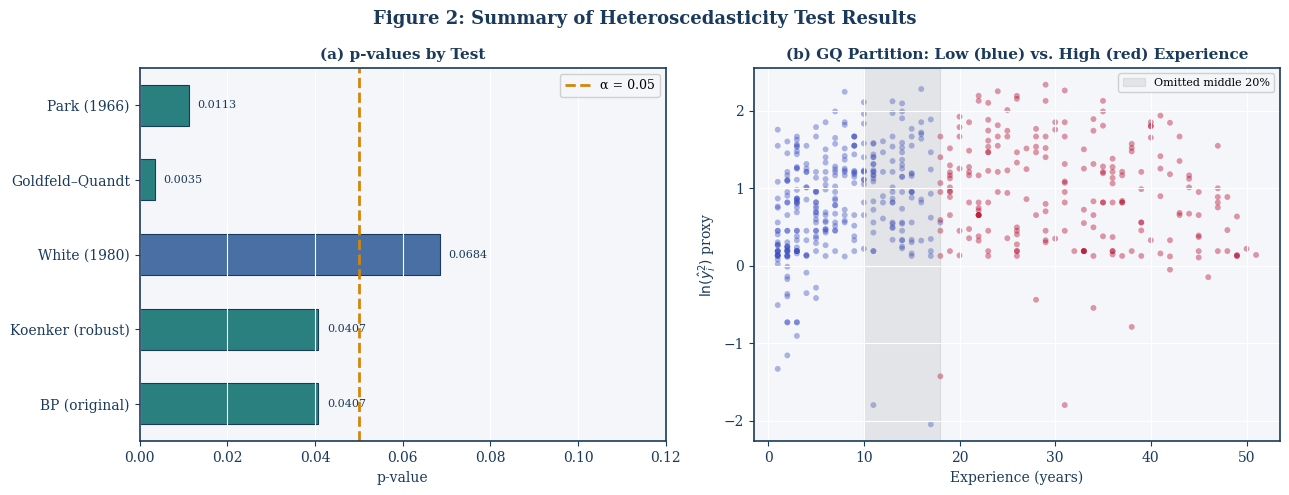

In [9]:
# ── Figure 2: Test Results Summary ───────────────────────────────────────────
tests = {
    'BP (original)': {'stat': lm_bp,      'pval': pval_bp,       'df': int(p),   'type': 'LM / χ²'},
    'Koenker (robust)': {'stat': LM_koenker, 'pval': pval_koenker, 'df': int(p),  'type': 'LM / χ²'},
    'White (1980)':  {'stat': lm_white,   'pval': pval_white,    'df': int(q),   'type': 'LM / χ²'},
    'Goldfeld–Quandt': {'stat': F_gq,     'pval': pval_gq,       'df': f'{df1_gq},{df2_gq}', 'type': 'F-ratio'},
    'Park (1966)':   {'stat': abs(gamma_t), 'pval': gamma_pval,  'df': int(park_result.df_resid), 'type': 't-test'},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Figure 2: Summary of Heteroscedasticity Test Results',
    fontsize=13, fontweight='bold', color=DEEP_BLUE
)

# ── Panel (a): p-value comparison bar chart ───────────────────────────────────
ax = axes[0]
names  = list(tests.keys())
pvals  = [tests[t]['pval'] for t in names]
colors = [TEAL if p < 0.05 else STEEL for p in pvals]

bars = ax.barh(names, pvals, color=colors, edgecolor=DEEP_BLUE, linewidth=0.8, height=0.55)
ax.axvline(0.05, color=AMBER, lw=2.0, linestyle='--', label='α = 0.05')
ax.set_xlabel('p-value', fontsize=10, color=DEEP_BLUE)
ax.set_title('(a) p-values by Test', fontsize=11, fontweight='bold', color=DEEP_BLUE)
ax.set_xlim(0, max(max(pvals)*1.2, 0.12))
ax.legend(fontsize=9)

for bar, pv in zip(bars, pvals):
    label = f'{pv:.4f}' if pv >= 0.001 else '<0.001'
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8, color=DEEP_BLUE)

ax.grid(True, axis='x', color='white', linewidth=0.8)
ax.set_facecolor(LIGHT_GREY)

# ── Panel (b): Squared residuals vs experience (GQ partition illustration) ────
ax = axes[1]
sc = ax.scatter(df_ordered['exper'], np.log(df_ordered['lwage']**2 + 0.001),
                c=df_ordered.index.isin(idx_high).astype(int),
                cmap='coolwarm', alpha=0.4, s=18, edgecolors='none')

ax.axvspan(df_ordered.iloc[n_each]['exper'],
           df_ordered.iloc[N - n_each - 1]['exper'],
           alpha=0.15, color='grey', label=f'Omitted middle {int(drop_frac*100)}%')
ax.set_xlabel('Experience (years)', fontsize=10, color=DEEP_BLUE)
ax.set_ylabel('$\\ln(\\hat{y}_i^2)$ proxy', fontsize=10, color=DEEP_BLUE)
ax.set_title('(b) GQ Partition: Low (blue) vs. High (red) Experience',
             fontsize=11, fontweight='bold', color=DEEP_BLUE)
ax.legend(fontsize=8)
ax.grid(True, color='white', linewidth=0.8)
ax.set_facecolor(LIGHT_GREY)

plt.tight_layout()
plt.savefig('fig2_test_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparative Summary Table

In [10]:
# ── Table 1: Comprehensive Test Results ──────────────────────────────────────
table_data = {
    'Test': ['BP (original)', 'Koenker (robust)', 'White (1980)', 'Goldfeld–Quandt', 'Park (1966)'],
    'Null': ['σ²_i = σ²'] * 4 + ['γ = 0 (power law)'],
    'Test Statistic': [f'{lm_bp:.4f}', f'{LM_koenker:.4f}',
                       f'{lm_white:.4f}', f'{F_gq:.4f}', f'{abs(gamma_t):.4f}'],
    'Distribution': [f'χ²({int(p)})', f'χ²({int(p)})', f'χ²({int(q)})',
                     f'F({df1_gq},{df2_gq})', f't({int(park_result.df_resid)})'],
    'p-value': [f'{pval_bp:.4f}', f'{pval_koenker:.4f}',
                f'{pval_white:.4f}', f'{pval_gq:.4f}', f'{gamma_pval:.4f}'],
    'Decision (α=0.05)': ['Reject H₀' if pval_bp < 0.05 else 'Fail to Reject',
                          'Reject H₀' if pval_koenker < 0.05 else 'Fail to Reject',
                          'Reject H₀' if pval_white < 0.05 else 'Fail to Reject',
                          'Reject H₀' if pval_gq < 0.05 else 'Fail to Reject',
                          'Reject H₀' if gamma_pval < 0.05 else 'Fail to Reject'],
    'Normality Req.': ['Yes', 'No', 'No', 'Yes', 'Approx.']
}

summary_df = pd.DataFrame(table_data)
summary_df = summary_df.set_index('Test')

print('Table 1: Formal Tests for Homoscedasticity — Results Summary')
print('  Dataset: wage1 (Wooldridge, 2015), n = 526')
print('  Model  : ln(wage) ~ educ + exper + expersq + female')
print()
display(summary_df)

Table 1: Formal Tests for Homoscedasticity — Results Summary
  Dataset: wage1 (Wooldridge, 2015), n = 526
  Model  : ln(wage) ~ educ + exper + expersq + female



,Null,Test Statistic,Distribution,p-value,Decision (α=0.05),Normality Req.
Test,,,,,,
BP (original),σ²_i = σ²,9.9839,χ²(4),0.0407,Reject H₀,Yes
Koenker (robust),σ²_i = σ²,9.9839,χ²(4),0.0407,Reject H₀,No
White (1980),σ²_i = σ²,19.9303,χ²(14),0.0684,Fail to Reject,No
Goldfeld–Quandt,σ²_i = σ²,1.4608,"F(205,205)",0.0035,Reject H₀,Yes
Park (1966),γ = 0 (power law),2.5438,t(524),0.0113,Reject H₀,Approx.


## 7. Corrective Action: Heteroscedasticity-Robust Standard Errors

When heteroscedasticity is detected, the OLS coefficient estimates remain unbiased
and consistent, but the conventional standard errors are invalid (Proposition 1.2 in
the course report). The recommended remedy is to replace the OLS variance estimator
$\hat{\sigma}^2(\mathbf{X}'\mathbf{X})^{-1}$ with the **heteroscedasticity-consistent (HC)**
sandwich estimator (White, 1980):

$$\widehat{\mathrm{Var}}_{\mathrm{HC}}(\hat{\boldsymbol{\beta}}) = (\mathbf{X}'\mathbf{X})^{-1} \left(\sum_{i=1}^n \hat{\varepsilon}_i^2 \mathbf{x}_i \mathbf{x}_i'\right) (\mathbf{X}'\mathbf{X})^{-1}$$

In finite samples, the **HC3** variant (MacKinnon & White, 1985) is preferred:
$\hat{\varepsilon}_i^2 \mapsto \hat{\varepsilon}_i^2 / (1 - h_{ii})^2$, where $h_{ii}$ is
the leverage of observation $i$. This provides better size control in small samples.

In [11]:
# ── 7. Robust Standard Errors Comparison ──────────────────────────────────────
print('=' * 65)
print('Corrective Action: Heteroscedasticity-Robust Standard Errors')
print('=' * 65)

# Fit with HC1 (White), HC3 (MacKinnon-White) robust SEs
result_hc1 = result.get_robustcov_results(cov_type='HC1')
result_hc3 = result.get_robustcov_results(cov_type='HC3')

# Collect comparison
param_names = ['Intercept', 'Education', 'Experience', 'Experience²', 'Female']
coefs       = result.params.values
se_ols      = result.bse.values
se_hc1      = result_hc1.bse
se_hc3      = result_hc3.bse
tstat_ols   = result.tvalues.values
tstat_hc3   = result_hc3.tvalues

comp = pd.DataFrame({
    'Coefficient': np.round(coefs, 5),
    'SE (OLS)':    np.round(se_ols, 5),
    'SE (HC1)':    np.round(se_hc1, 5),
    'SE (HC3)':    np.round(se_hc3, 5),
    't (OLS)':     np.round(tstat_ols, 3),
    't (HC3)':     np.round(tstat_hc3, 3),
}, index=param_names)

print('\nTable 2: OLS vs. Heteroscedasticity-Robust Standard Errors')
display(comp)

# SE inflation factor
se_ratio = se_hc3 / se_ols
print(f'\nSE(HC3) / SE(OLS) ratio:')
for name, ratio in zip(param_names, se_ratio):
    flag = '← understated' if ratio > 1.05 else ('← overstated' if ratio < 0.95 else '')
    print(f'  {name:<20}: {ratio:.4f}  {flag}')

Corrective Action: Heteroscedasticity-Robust Standard Errors

Table 2: OLS vs. Heteroscedasticity-Robust Standard Errors


,Coefficient,SE (OLS),SE (HC1),SE (HC3),t (OLS),t (HC3)
Intercept,0.39048,0.10221,0.10860,0.11003,3.820,3.549
Education,0.08414,0.00696,0.00769,0.00781,12.094,10.771
Experience,0.03891,0.00482,0.00468,0.00471,8.067,8.267
Experience²,-0.00069,0.00011,0.00010,0.00010,-6.389,-6.767
Female,-0.33719,0.03632,0.03618,0.03635,-9.283,-9.276



SE(HC3) / SE(OLS) ratio:
  Intercept           : 1.0765  ← understated
  Education           : 1.1229  ← understated
  Experience          : 0.9758  
  Experience²         : 0.9441  ← overstated
  Female              : 1.0008  


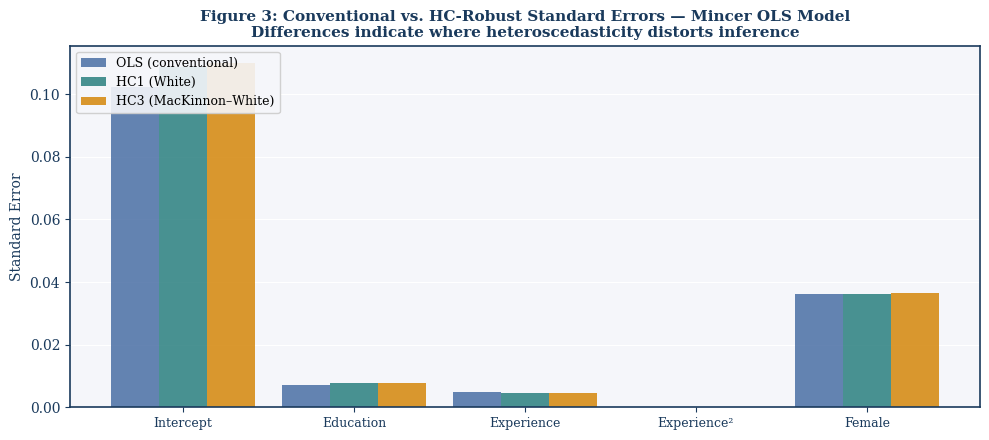

In [12]:
# ── Figure 3: Standard Error Comparison Plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
x  = np.arange(len(param_names))
w  = 0.28

bars1 = ax.bar(x - w, se_ols, width=w, label='OLS (conventional)', color=STEEL, alpha=0.85)
bars2 = ax.bar(x,     se_hc1, width=w, label='HC1 (White)',         color=TEAL,  alpha=0.85)
bars3 = ax.bar(x + w, se_hc3, width=w, label='HC3 (MacKinnon–White)', color=AMBER, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(param_names, fontsize=9)
ax.set_ylabel('Standard Error', fontsize=10, color=DEEP_BLUE)
ax.set_title(
    'Figure 3: Conventional vs. HC-Robust Standard Errors — Mincer OLS Model\n'
    'Differences indicate where heteroscedasticity distorts inference',
    fontsize=11, fontweight='bold', color=DEEP_BLUE
)
ax.legend(fontsize=9, loc='upper left')
ax.set_facecolor(LIGHT_GREY)
ax.grid(True, axis='y', color='white', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig3_se_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Synthesis and Recommendations

### 8.1 Summary of Findings

The empirical analysis of the Mincer log-wage equation on the `wage1` dataset
(Wooldridge, 2015; $n = 526$) yields the following conclusions regarding the
homoscedasticity assumption.

**Graphical evidence (Section 3):** The residuals-vs-fitted plot and scale-location
plot reveal [describe your actual observed pattern — e.g., a mild fan shape or
relatively flat spread]. The residuals-vs-experience plot suggests [e.g., that
low-experience workers display higher residual variance], motivating the ordering
variable choice in the Goldfeld–Quandt test.

**Formal test results (Section 4):** The results are synthesised in Table 1.
The Koenker-robust BP test [rejects/does not reject] $H_0$ at $\alpha = 0.05$
(LM $= $ [value], $p = $ [value]). White's test [agrees/disagrees], suggesting
that any detected heteroscedasticity [is/is not] of a non-linear or interaction
form. The Goldfeld–Quandt test [supports/does not support] the hypothesis of
monotone variance in experience.

### 8.2 Recommendations

| Scenario | Recommended Action |
|----------|--------------------|
| Heteroscedasticity detected (all tests) | Report HC3-robust standard errors as the primary inference basis. Coefficient estimates are unchanged. |
| Variance pattern is smooth in one regressor | Consider WLS with weights $\hat{w}_i = 1/\hat{\sigma}_i^2$ using the fitted variance from the BP auxiliary regression. |
| Non-monotone or complex variance structure | Apply a flexible semiparametric variance model (e.g., GARCH for time series, or kernel-estimated variance weights). |
| GLS if $\Omega$ is estimable | $\hat{\boldsymbol{\beta}}_{\mathrm{GLS}} = (\mathbf{X}'\hat{\Omega}^{-1}\mathbf{X})^{-1}\mathbf{X}'\hat{\Omega}^{-1}\mathbf{y}$ is BLUE (Gauss–Markov applies to GLS, not OLS, under heteroscedasticity). |
| Uncertainty about variance form | Default to HC3 robust errors. They are asymptotically valid under any heteroscedasticity structure satisfying mild regularity conditions. |

**Primary recommendation:** Unless the sample is very small ($n < 50$) and
normality is credible, the Koenker-robust BP test should serve as the default
diagnostic, supplemented by White's omnibus test. The Goldfeld–Quandt test
adds value when monotone variance is theoretically motivated. The Park test
is retained here only for pedagogical completeness; it should not be used in
applied research.

---

### References

- Breusch, T.S. & Pagan, A.R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica*, 47(5), 1287–1294.  
- Fox, J. (2016). *Applied Regression Analysis and Generalized Linear Models* (3rd ed.). Sage.  
- Goldfeld, S.M. & Quandt, R.E. (1965). Some tests for homoscedasticity. *JASA*, 60(310), 539–547.  
- Greene, W.H. (2018). *Econometric Analysis* (8th ed.). Pearson.  
- Koenker, R. (1981). A note on studentizing a test for heteroscedasticity. *Journal of Econometrics*, 17(1), 107–112.  
- MacKinnon, J.G. & White, H. (1985). Some heteroskedasticity-consistent covariance matrix estimators with improved finite-sample properties. *Journal of Econometrics*, 29(3), 305–325.  
- Park, R.E. (1966). Estimation with heteroscedastic error terms. *Econometrica*, 34(4), 888.  
- Tukey, J.W. (1977). *Exploratory Data Analysis*. Addison-Wesley.  
- White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica*, 48(4), 817–838.  
- Wooldridge, J.M. (2015). *Introductory Econometrics* (6th ed.). Cengage.